# 03 · Search space, the fit and its result

The search space is everything an equation may contain:

* the variables and their derivatives, always present, with powers up to the
  configured limits;
* **token families** added by the user: coordinates, sine and cosine, constants,
  fields supplied as arrays (forcing, coefficients), custom functions;
* limits on the size of an equation: the number of terms and the number of
  factors in one term.

Families that need only numbers are declared in the configuration; families that
need arrays or functions are passed to the search as objects.

Displayed outputs are saved examples from earlier executions and do not verify the current version. Re-execute the relevant cells to obtain current results. Searches may reuse a compatible saved run; the printed status identifies this. Recovered laws are established by the reported term comparison, rather than by the presence of a plotted equation.

In [1]:
import os, sys, time
from pathlib import Path
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')   # before numpy: EPDE is faster single-threaded
os.environ.setdefault('OMP_NUM_THREADS', '1')

# find projects/pic (this notebook lives in projects/pic/notebooks)
PIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'epde_bench').is_dir())
sys.path[:0] = [str(PIC.parent.parent), str(PIC)]
import epde

import numpy as np
import matplotlib.pyplot as plt
from epde_bench import datasets, metrics, load_config, resolve_for_problem, discover
from epde_bench.plotting import plot_problem, plot_front
from epde_bench.truthcheck import check, print_check
from epde_bench.nbcache import cached_run, print_run
import epde_bench.nbcache as notebook_cache
if os.environ.get('EPDE_BENCH_NOTEBOOK_CACHE'):
    notebook_cache.CACHE_DIR = Path(os.environ['EPDE_BENCH_NOTEBOOK_CACHE'])
from epde_bench.env import seed_everything
seed_everything(0)
print('Search cache:', notebook_cache.CACHE_DIR)
from epde_bench.reconstruction import plot_reconstruction
%matplotlib inline
print('EPDE imported; notebook environment ready')

Search cache: <repo>/projects/pic/results/notebook_execution_2026-10-09/search_cache
EPDE imported; notebook environment ready


## Families available by name

In [2]:
from epde.interface.search_config import TOKEN_REGISTRY
for name, cls in TOKEN_REGISTRY.items():
    print(f'{name:18} -> {cls}')

trigonometric      -> TrigonometricTokens
phased_sine_1d     -> PhasedSine1DTokens
grid               -> GridTokens
data_polynomials   -> DataPolynomials
data_sign          -> DataSign
constant           -> ConstantToken
velocity_heq       -> VelocityHEQTokens
logfun             -> LogfunTokens


## Fields supplied as arrays

A forcing input or a coefficient field enters as a stored token. A token that may
stand alone in a term (a forcing) is marked as meaningful; one that may only
multiply other factors (a coupling coefficient) is not. The flexible robot arm is
driven by a measured torque:

forcing ['u_in'] may stand alone


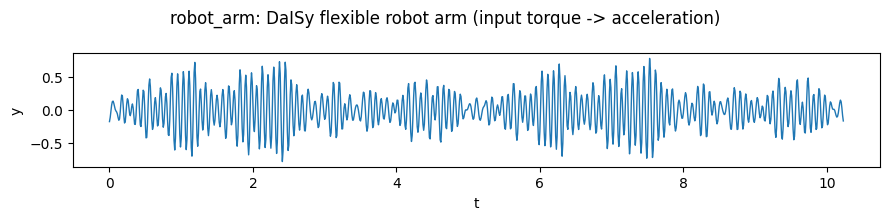

In [3]:
p = datasets.load('robot_arm')
for token_type, tensors, meaningful in p.token_groups:
    print(token_type, list(tensors), 'may stand alone' if meaningful else 'factor only')
plot_problem(p); plt.show()

## Sine and cosine with a known frequency

The forced oscillator needs $\sin(2t)$. The library's trigonometric family takes
an interval of frequencies and treats frequencies more than 5 % of the interval
width apart as different tokens. With a very narrow interval around 2, numerically
equal functions become separate tokens, and the search can combine them into exact
identities with zero error and zero instability. The examples here therefore use
a family with exactly one frequency; it prints the same token names.

The two runs below differ only in this family.

In [4]:
rec = cached_run('ode', variant='trig_native', noise=0.0, seed=0)
print_run(rec)

trig_token_params: VALUES = (0, 0)
Set self._mem_for_cache as 2
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11d58acf0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11d58acf0>
Set domain <epde.structure.domain.Domain object at 0x11d8196a0> with inner shape of [256]
Deriv orders after definition [[0], [0, 0]]
Added trajectory 0 to exist. traj: dict_keys([])
The cardinality of defined token pool is [1 2 1 2]
Among them, the pool contains [1 2 1]
No x data in cache for constancy check. Functionality of eval-d token check TBD.
No sin data in cache for constancy check. Functionality of eval-d token check TBD.
No cos data in cache for constancy check. Functionality of eval-d token check TBD.
self.vars_demand_equation {'u'}
[0.25532351 0.02063242]


[0.90800928 0.53433718]


[0.29241043 0.05770276]
[0.92309867 0.93952456]
[0.48900774 0.26260914]
[0.75873811 0.24128528]
[0.19393863 0.08842266]
[0.34073304 0.08563158]
[0.8237885  0.54070232]
[0.84629277 0.18917123]
[0.80023219 0.61000602]
[0.48727795 0.16073658]
[0.37104351 0.04084596]
[0.71309073 0.05937333]
[0.92729825 0.3211381 ]
[0.78899284 0.0283499 ]
[0.20956231 0.01335201]


[1.24920950e-02 8.33617725e-05]


[0.14639578 0.06176739]
[0.1838795  0.01181679]
[0.78608092 0.00336365]
[0.39295985 0.15632818]
[0.11989148 0.03184261]


...

[0.93332914 0.00566037]
[0.24459483 0.18015142]
[0.22835352 0.15943123]
[0.3413436  0.26594707]
[0.28035024 0.00647306]
[0.8835596  0.47263387]
[0.50962692 0.29654752]
[0.12996631 0.04487453]


[0.71284118 0.1725779 ]
[0.48285443 0.31979254]
[0.12458843 0.02857166]
[0.52571231 0.48615036]
[0.0047417  0.03025176]


[0.22314108 0.16296082]
[0.77321091 0.02155716]
[0.26860322 0.05687571]
[0.73707473 0.1083103 ]
[0.00474171 0.03025155]
[0.39786363 0.45063541]
[0.10134129 0.02930568]
[0.75224076 0.44927023]


[0.19060672 0.02516551]
[0.24546169 0.01326199]
[0.21607824 0.00545867]
[0.45411494 0.0829471 ]
[1.24921131e-02 8.33619864e-05]


[0.15672777 0.14971591]
[0.55152502 0.19229595]
[0.40106298 0.02174072]
[0.64608487 0.00379646]
[0.31956969 0.03217172]
[0.82130306 0.50632111]
The optimization has been conducted.
ok fit 13 s 
[0] <- compromise pick
     0.0007816242037613724 * x{power: 2.0, dim: 0.0} * sin{power: 1.0, freq: 2.0000000078573663, dim: 0.0} + 1.0000000046351767 * du/dx0{power: 1.0} * cos{power: 1.0, freq: 2.000000005121607, dim: 0.0} + -0.0007816241683311483 * x{power: 2.0, dim: 0.0} * sin{power: 1.0, freq: 2.0000000045860387, dim: 0.0} + 0.0 = du/dx0{power: 1.0} * cos{power: 1.0, freq: 2.000000006670756, dim: 0.0}
{'front_size': 1, 'selected_index': 0, 'success_front': False, 'success_selected': False, 'hamming_min': 6, 'hamming_selected': 6, 'coef_error': None}


In [5]:
rec = cached_run('ode', variant='default', noise=0.0, seed=0)
print_run(rec)

Set self._mem_for_cache as 2
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11d76bed0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11d76bed0>
Set domain <epde.structure.domain.Domain object at 0x11d76a350> with inner shape of [256]
Deriv orders after definition [[0], [0, 0]]
Added trajectory 0 to exist. traj: dict_keys([])
The cardinality of defined token pool is [1 2 1 2]
Among them, the pool contains [1 2 1]
No x data in cache for constancy check. Functionality of eval-d token check TBD.
No sin data in cache for constancy check. Functionality of eval-d token check TBD.
No cos data in cache for constancy check. Functionality of eval-d token check TBD.
self.vars_demand_equation {'u'}
[0.25532351 0.02063242]
[0.90800928 0.53433718]
[0.8166902  0.48805141]
[0.92309867 0.93952456]
[0.7522408  0.44927028]
[0.5393603  0.16059395]
[0.61637023 0.01400645]
[0.26018341 0.00145246]
[0.10510912 0.00717222]
[0.38302503 0.02189376]


[0.25491606 0.02859971]
[0.8835596  0.47263387]
[0.97900759 0.78028055]
[0.90157047 0.26629973]
[0.81354145 0.45252137]
[0.29668756 0.61871978]
[0.37104351 0.04084596]
[0.26611412 0.07210758]
[0.30079419 0.00499956]
[0.1780458  0.14269931]
[0.18668286 0.00436271]
[0.13048008 0.05469681]
[0.15656736 0.02867927]


[0.24778972 0.00590464]
[1.24921014e-02 8.33618480e-05]
[0.41655515 0.00424108]
[0.15703811 0.10810395]
[0.80820807 0.00715694]
[0.24372489 0.06769309]
[0.51437209 0.14211829]
[0.43736575 0.0547071 ]


[0.35309864 0.07873307]
[0.70126805 0.23056898]
[0.1838795  0.01181679]
[0.19556076 0.12143848]
[0.20956231 0.01335201]
[0.2588542  0.36867772]
[0.22717865 0.05842868]
[0.25630806 0.15762039]
[0.32387725 0.03087728]
[0.50962692 0.29654754]
[0.76542516 0.15802738]
[0.10076118 0.04749676]
[0.24890563 0.02558256]


[0.56373087 0.15673327]
[0.4661096  0.37587514]
[0.2889397  0.57918214]
[0.34488741 0.02525217]
[0.35004387 0.08547149]
[0.08347604 0.05494341]
[0.14014317 0.1637234 ]


...

[0.12883813 0.0281182 ]
[0.12991599 0.08460667]
[0.66335024 0.02549884]
[0.23849237 0.04583318]
[0.59687853 0.23069461]


[0.12454601 0.0127077 ]


[0.08879425 0.01041486]
[0.39595518 0.02121699]
[0.33611763 0.00753164]


[0.24420611 0.0615404 ]
[0.4648183  0.02152215]
[0.49853187 0.1185448 ]
[0.07737314 0.01675717]
[0.43321611 0.05276285]


[0.32905747 0.21271785]
The optimization has been conducted.
ok fit 16 s 
[0] <- compromise pick
     -3.98448568355491 * u{power: 1.0} + 1.4969734589992256 * x{power: 1.0, dim: 0.0} + -0.9885206385764272 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 0.0 = d^2u/dx0^2{power: 1.0}
{'front_size': 1, 'selected_index': 0, 'success_front': True, 'success_selected': True, 'hamming_min': 0, 'hamming_selected': 0, 'coef_error': 0.005791878178453848}


## Reading the result

The search ends with a population of non-dominated equations. For each of them
the result holds the equation and its objective values: the discrepancy first,
then the second objective (by default the coefficient instability).

Without the known law, one equation still has to be chosen. Here it is the
compromise point: the smallest sum of objectives normalised over the front.

Set self._mem_for_cache as 2
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11d76a350>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x11d76a350>
Set domain <epde.structure.domain.Domain object at 0x11d587890> with inner shape of [256]
Deriv orders after definition [[0], [0, 0]]
Added trajectory 0 to exist. traj: dict_keys([])
The cardinality of defined token pool is [1 2 1 2]
Among them, the pool contains [1 2 1]
No x data in cache for constancy check. Functionality of eval-d token check TBD.
No sin data in cache for constancy check. Functionality of eval-d token check TBD.
No cos data in cache for constancy check. Functionality of eval-d token check TBD.
self.vars_demand_equation {'u'}
[0.99324087 0.23963641]
[0.99735566 0.32517847]
[0.99456086 0.40355744]
[0.99103818 0.38697096]
[0.99950319 0.88765583]
[0.98456208 0.09834805]
[0.84192407 0.52728124]
[0.98681261 0.27420639]
[0.99828173 0.51983668]


[0.95250665 0.23170758]
[0.90683235 0.06833301]
[0.97225295 0.23661148]
[0.93903054 0.33918825]
[0.91163452 0.20118587]


[0.85607739 0.4331302 ]
[0.8430438  0.11334924]
[0.85555768 0.8865856 ]
[0.83925851 0.36030232]


[0.90220889 0.39643942]
[0.98747257 0.75910687]
[0.90595173 0.1814809 ]


[0.93004394 0.18246632]
[0.77462486 0.03086923]
[0.94168926 0.34339271]
[0.84789856 0.37975627]


...

Could not generate unique offspring
Could not generate unique offspring
[0.9559501  0.36923308]


Could not generate unique offspring
Could not generate unique offspring


Could not generate unique offspring
Could not generate unique offspring


Could not generate unique offspring
[0.88772492 0.20264629]


Could not generate unique offspring
Could not generate unique offspring
The optimization has been conducted.
ok fit 30 s 
[0]
     0.10758555645810124 * x{power: 1.0, dim: 0.0} * cos{power: 1.0, freq: 2.0, dim: 0.0} + -0.08397142485412876 * x{power: 1.0, dim: 0.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 0.0 = du/dx0{power: 1.0} * u{power: 1.0}
[1]
     0.1005516818435371 * u{power: 2.0} * x{power: 1.0, dim: 0.0} + -0.1919939301089805 * x{power: 1.0, dim: 0.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + -0.012609848342927641 * x{power: 2.0, dim: 0.0} + 0.0 = u{power: 1.0} * du/dx0{power: 1.0}
[2] <- compromise pick
     0.00895608186282935 * x{power: 2.0, dim: 0.0} + -0.0055649325406030336 * x{power: 2.0, dim: 0.0} * u{power: 2.0} + 0.16440101294320794 * x{power: 1.0, dim: 0.0} * cos{power: 1.0, freq: 2.0, dim: 0.0} + 0.0 = u{power: 1.0} * du/dx0{power: 1.0}
{'front_size': 3, 'selected_index': 2, 'success_front': False, 'success_selected': False, 'hamming_min': 7, 'hamming_selected': 8, '

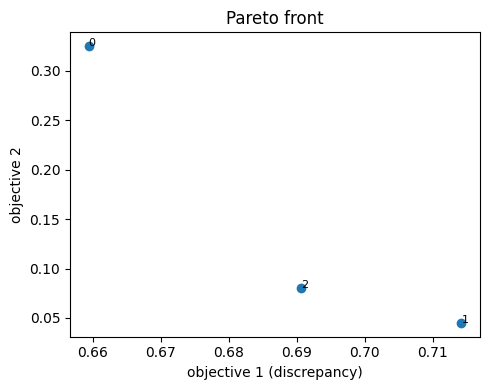

compromise pick: 2


In [6]:
rec = cached_run('vdp', variant='default', noise=5.0, seed=0)
print_run(rec)
plot_front(rec.get('objectives', [])); plt.show()
print('compromise pick:', metrics.select_compromise(rec.get('objectives', [])))

## Scoring against the known law

The benchmark compares **sets of terms**, not coefficients: a run succeeds when
an equation of the front (or the compromise pick) has exactly the true terms.
Documented equivalent forms count as correct. The relative error of the
coefficients is reported separately.

In [7]:
rec = cached_run('ode', variant='default', noise=0.0, seed=0)
problem = datasets.load('ode')
print(metrics.score_run(rec['front'], rec['objectives'], problem.truth_systems))

{'front_size': 1, 'selected_index': 0, 'success_front': True, 'success_selected': True, 'hamming_min': 0, 'hamming_selected': 0, 'best_index': 0, 'coef_error': 0.005791878178453848}
